# 10 — Why does sequential calibration help interval performance?
This post-hoc mechanism study uses the retained forecasts from notebook 09; it does not refit or tune models. The 90% interval score is decomposed exactly into interval width, lower-tail miss penalty, and upper-tail miss penalty. Results are then separated by asset and by information available before each forecast: trailing 20-day realized volatility. Because these hypotheses were prompted by observed regime results, they are explanatory rather than confirmatory.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.evaluation import distribution_shift_summary, summarize_components_by_state, summarize_interval_components
SOURCE = ROOT / 'results' / 'market_regimes'
OUT = ROOT / 'results' / 'interval_mechanisms'; OUT.mkdir(parents=True, exist_ok=True)
ASSETS = ['AAPL', 'JPM', 'XOM', 'WMT']

In [2]:
returns = pd.read_csv(ROOT / 'data' / 'processed' / 'financial_returns.csv', index_col=0, parse_dates=True)[ASSETS].dropna().sort_index()
PERIODS = {
    'pre_pandemic': ('2007-01-01', '2014-12-31', '2017-01-01', '2019-12-31'),
    'pandemic': ('2007-01-01', '2016-12-31', '2020-01-01', '2021-12-31'),
    'inflation_tightening': ('2007-01-01', '2019-12-31', '2022-01-01', '2023-12-31'),
    'recent': ('2007-01-01', '2021-12-31', '2024-01-01', '2025-12-31'),
}
archives = {}
for regime in PERIODS:
    archive = np.load(SOURCE / f'{regime}_forecasts.npz')
    names = [str(value) for value in archive['model_names']]
    if len(names) == 3 and 'CA-RNN (temporal penalty removed)' not in names:
        names = ['RNN', 'CA-RNN (temporal penalty removed)', 'CA-RNN']
    archives[regime] = {'target': archive['target'], 'forecasts': {name: archive[f'samples_{i}'] for i, name in enumerate(names)}}
print('Loaded retained forecasts for', ', '.join(archives))

Loaded retained forecasts for pre_pandemic, pandemic, inflation_tightening, recent


## Exact score decomposition
For nominal miscoverage $\alpha=0.10$, the interval score is $W+(2/\alpha)(L-Y)\mathbf 1(Y<L)+(2/\alpha)(Y-U)\mathbf 1(Y>U)$. Hence every change is exactly the sum of a width change and changes in the two tail penalties.

In [3]:
component_rows = []
for regime, stored in archives.items():
    for model, seed_forecasts in stored['forecasts'].items():
        for seed_index, samples in enumerate(seed_forecasts):
            frame = summarize_interval_components(stored['target'], samples, ASSETS)
            frame.insert(0, 'seed_index', seed_index); frame.insert(0, 'model', model); frame.insert(0, 'regime', regime)
            component_rows.append(frame)
components = pd.concat(component_rows, ignore_index=True)
overall = components[components.asset.eq('all')]
means = overall.groupby(['regime', 'model'])[['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage', 'predictive_sd', 'absolute_error']].mean()
display(means)
components.to_csv(OUT / 'interval_components_by_asset_seed.csv', index=False)

width  \
regime               model                                         
inflation_tightening CA-RNN                             2.890508   
                     CA-RNN (temporal penalty removed)  2.754550   
                     RNN                                2.656343   
pandemic             CA-RNN                             2.758906   
                     CA-RNN (temporal penalty removed)  2.634697   
                     RNN                                2.716934   
pre_pandemic         CA-RNN                             2.184501   
                     CA-RNN (temporal penalty removed)  2.172322   
                     RNN                                2.228438   
recent               CA-RNN                             2.345776   
                     CA-RNN (temporal penalty removed)  2.297349   
                     RNN                                2.364308   

                                                        lower_penalty  \
regime               model                                              
inflation_tightening CA-RNN                                  0.874293   
                     CA-RNN (temporal penalty removed)       0.970758   
                     RNN                                     1.045221   
pandemic             CA-RNN                                  1.378859   
                     CA-RNN (temporal penalty removed)       1.511059   
                     RNN                                     1.438801   
pre_pandemic         CA-RNN                                  0.492107   
                     CA-RNN (temporal penalty removed)       0.507887   
                     RNN                                     0.468051   
recent               CA-RNN                                  0.719007   
                     CA-RNN (temporal penalty removed)       0.752459   
                     RNN                                     0.692227   

                                                        upper_penalty  \
regime               model                                              
inflation_tightening CA-RNN                                  0.774819   
                     CA-RNN (temporal penalty removed)       0.863294   
                     RNN                                     0.884644   
pandemic             CA-RNN                                  1.525115   
                     CA-RNN (temporal penalty removed)       1.665320   
                     RNN                                     1.581370   
pre_pandemic         CA-RNN                                  0.426108   
                     CA-RNN (temporal penalty removed)       0.428592   
                     RNN                                     0.415853   
recent               CA-RNN                                  0.628744   
                     CA-RNN (temporal penalty removed)       0.670226   
                     RNN                                     0.608257   

                                                        interval_score  \
regime               model                                               
inflation_tightening CA-RNN                                   4.539620   
                     CA-RNN (temporal penalty removed)        4.588601   
                     RNN                                      4.586208   
pandemic             CA-RNN                                   5.662879   
                     CA-RNN (temporal penalty removed)        5.811076   
                     RNN                                      5.737105   
pre_pandemic         CA-RNN                                   3.102716   
                     CA-RNN (temporal penalty removed)        3.108802   
                     RNN                                      3.112342   
recent               CA-RNN                                   3.693527   
                     CA-RNN (temporal penalty removed)        3.720035   
                     RNN                                      3.664792   

                       

In [4]:
wide = overall.set_index(['regime', 'seed_index', 'model'])
rows = []
for regime in PERIODS:
    for comparator in ['RNN', 'CA-RNN (temporal penalty removed)']:
        candidate = wide.loc[(regime, slice(None), 'CA-RNN'), :]
        baseline = wide.loc[(regime, slice(None), comparator), :]
        candidate.index = candidate.index.droplevel(['regime', 'model'])
        baseline.index = baseline.index.droplevel(['regime', 'model'])
        for metric in ['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage', 'predictive_sd', 'absolute_error']:
            difference = candidate[metric] - baseline[metric]
            rows.append({'regime': regime, 'comparison': f'sequential minus {comparator}', 'component': metric, 'mean_difference': difference.mean(), 'seed_sd': difference.std(ddof=1), 'seeds_below_zero': int((difference < 0).sum())})
differences = pd.DataFrame(rows)
display(differences[differences.comparison.eq('sequential minus RNN')].pivot(index='regime', columns='component', values='mean_difference'))
differences.to_csv(OUT / 'component_paired_differences.csv', index=False)

component,absolute_error,coverage,interval_score,lower_penalty,predictive_sd,upper_penalty,width
regime,,,,,,,
inflation_tightening,0.007044,0.023852,-0.046588,-0.170928,0.071387,-0.109824,0.234165
pandemic,0.003831,0.003168,-0.074226,-0.059942,0.013050,-0.056255,0.041972
pre_pandemic,0.001543,-0.004973,-0.009626,0.024056,-0.013464,0.010256,-0.043937
recent,0.003774,-0.006175,0.028735,0.026780,-0.005728,0.020488,-0.018533


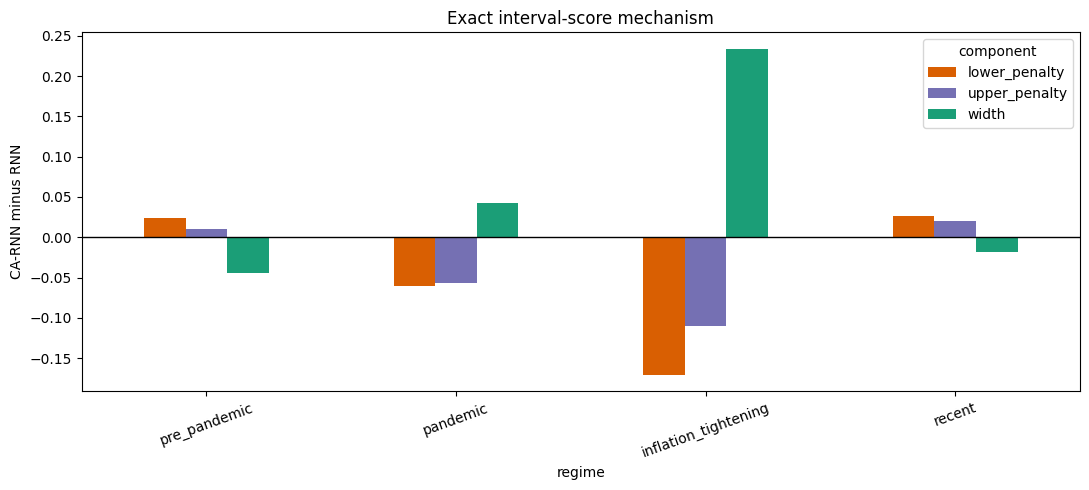

In [5]:
plot = differences[differences.comparison.eq('sequential minus RNN') & differences.component.isin(['width', 'lower_penalty', 'upper_penalty'])]
pivot = plot.pivot(index='regime', columns='component', values='mean_difference').reindex(PERIODS)
axis = pivot.plot(kind='bar', figsize=(11, 5), color=['#d95f02', '#7570b3', '#1b9e77'])
axis.axhline(0, color='black', linewidth=1); axis.set_ylabel('CA-RNN minus RNN'); axis.set_title('Exact interval-score mechanism'); axis.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(OUT / 'interval_score_decomposition.png', dpi=180, bbox_inches='tight')

## Asset and pre-forecast volatility diagnostics
Volatility states use only returns available before the target date. Terciles are defined within each test regime to retain adequate sample sizes. Conditioning on a realized market regime is descriptive and does not identify a causal mechanism.

In [6]:
asset_means = components[~components.asset.eq('all')].groupby(['regime', 'model', 'asset'])[['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage']].mean().reset_index()
asset_pivot = asset_means.pivot(index=['regime', 'asset'], columns='model', values='interval_score')
asset_pivot['CA-RNN_minus_RNN'] = asset_pivot['CA-RNN'] - asset_pivot['RNN']
display(asset_pivot[['CA-RNN_minus_RNN']])
asset_means.to_csv(OUT / 'asset_component_means.csv', index=False)

model                       CA-RNN_minus_RNN
regime               asset                  
inflation_tightening AAPL          -0.005119
                     JPM            0.022068
                     WMT            0.033108
                     XOM           -0.236407
pandemic             AAPL          -0.055454
                     JPM            0.023558
                     WMT           -0.120575
                     XOM           -0.144431
pre_pandemic         AAPL          -0.038155
                     JPM           -0.016483
                     WMT            0.014478
                     XOM            0.001656
recent               AAPL           0.023990
                     JPM           -0.008843
                     WMT            0.033271
                     XOM            0.066521

In [7]:
state_rows = []
shift_rows = []
trailing_volatility = returns.rolling(20).std().mean(axis=1).shift(1)
for regime, (train_start, train_end, test_start, test_end) in PERIODS.items():
    train_values = returns.loc[train_start:train_end].to_numpy()
    test_frame = returns.loc[test_start:test_end]
    assert len(test_frame) == len(archives[regime]['target'])
    shift_rows.append({'regime': regime, **distribution_shift_summary(train_values, test_frame.to_numpy())})
    state_codes = pd.qcut(trailing_volatility.loc[test_frame.index], 3, labels=False).to_numpy()
    state = np.asarray(['low', 'medium', 'high'])[state_codes]
    for model, seed_forecasts in archives[regime]['forecasts'].items():
        for seed_index, samples in enumerate(seed_forecasts):
            frame = summarize_components_by_state(archives[regime]['target'], samples, state, ['low', 'medium', 'high'])
            frame.insert(0, 'seed_index', seed_index); frame.insert(0, 'model', model); frame.insert(0, 'regime', regime)
            state_rows.append(frame)
states = pd.concat(state_rows, ignore_index=True)
shifts = pd.DataFrame(shift_rows)
display(shifts)
display(states.groupby(['regime', 'state', 'model'])[['width', 'lower_penalty', 'upper_penalty', 'interval_score', 'coverage']].mean())
states.to_csv(OUT / 'components_by_preforecast_volatility.csv', index=False)
shifts.to_csv(OUT / 'regime_shift_descriptors.csv', index=False)

,regime,mean_volatility_ratio,max_volatility_ratio,correlation_shift_frobenius,standardized_location_shift,mean_standardized_fourth_moment
0,pre_pandemic,0.692760,0.979962,0.392111,0.045541,6.103827
1,pandemic,1.260769,1.697840,0.530085,0.045150,29.874353
2,inflation_tightening,1.000215,1.289820,0.541889,0.081833,12.079110
3,recent,0.830223,1.057265,0.569400,0.102708,6.370406


width  \
regime               state  model                                         
inflation_tightening high   CA-RNN                             3.662855   
                            CA-RNN (temporal penalty removed)  3.456708   
                            RNN                                3.169248   
                     low    CA-RNN                             2.178402   
                            CA-RNN (temporal penalty removed)  2.109147   
                            RNN                                2.181468   
                     medium CA-RNN                             2.830267   
                            CA-RNN (temporal penalty removed)  2.697795   
                            RNN                                2.618313   
pandemic             high   CA-RNN                             3.874842   
                            CA-RNN (temporal penalty removed)  3.651583   
                            RNN                                3.729958   
                     low    CA-RNN                             2.106669   
                            CA-RNN (temporal penalty removed)  2.044797   
                            RNN                                2.148397   
                     medium CA-RNN                             2.299089   
                            CA-RNN (temporal penalty removed)  2.211223   
                            RNN                                2.275831   
pre_pandemic         high   CA-RNN                             2.768019   
                            CA-RNN (temporal penalty removed)  2.602512   
                            RNN                                2.735801   
                     low    CA-RNN                             1.842939   
                            CA-RNN (temporal penalty removed)  1.917777   
                            RNN                                1.930987   
                     medium CA-RNN                             1.940609   
                            CA-RNN (temporal penalty removed)  1.995272   
                            RNN                                2.016846   
recent               high   CA-RNN                             2.807874   
                            CA-RNN (temporal penalty removed)  2.754925   
                            RNN                                2.774859   
                     low    CA-RNN                             2.040186   
                            CA-RNN (temporal penalty removed)  1.994006   
                            RNN                                2.094108   
                     medium CA-RNN                             2.187381   
                            CA-RNN (temporal penalty removed)  2.141259   
                            RNN                                2.222267   

                                                               lower_penalty  \
regime               state  model                                              
inflation_tightening high   CA-RNN                                  1.048393   
                            CA-RNN (temporal penalty removed)       1.159824   
                            RNN                                     1.383936   
                     low    CA-RNN                                  0.676002   
                            CA-RNN (temporal penalty removed)       0.725024   
                            RNN                                     0.702060   
                     medium CA-RNN                                  0.898484   
                            CA-RNN (temporal penalty removed)       1.027424   
                            RNN                                     1.049667   
pandemic             high   CA-RNN                                  2.066625   
                            CA-RNN (temporal penalty removed)       2.299636   
                            RNN                                     2.315338   
                     low    CA-RNN                                  0.872416   
               

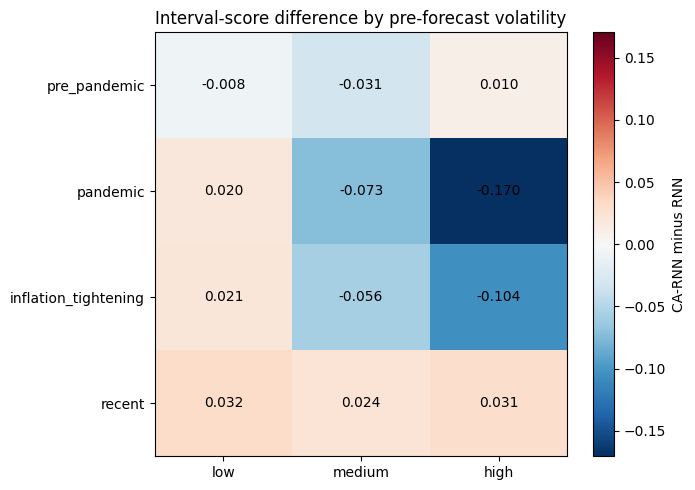

In [8]:
state_means = states.groupby(['regime', 'state', 'model'])['interval_score'].mean().unstack('model')
state_means['CA-RNN_minus_RNN'] = state_means['CA-RNN'] - state_means['RNN']
heatmap = state_means['CA-RNN_minus_RNN'].unstack('state').reindex(index=PERIODS, columns=['low', 'medium', 'high'])
fig, axis = plt.subplots(figsize=(7, 5))
image = axis.imshow(heatmap, cmap='RdBu_r', aspect='auto', vmin=-np.abs(heatmap.to_numpy()).max(), vmax=np.abs(heatmap.to_numpy()).max())
axis.set_xticks(range(3), heatmap.columns); axis.set_yticks(range(len(heatmap)), heatmap.index); axis.set_title('Interval-score difference by pre-forecast volatility')
for i in range(len(heatmap)):
    for j in range(3): axis.text(j, i, f'{heatmap.iloc[i, j]:.3f}', ha='center', va='center')
fig.colorbar(image, ax=axis, label='CA-RNN minus RNN'); plt.tight_layout()
fig.savefig(OUT / 'volatility_state_interval_difference.png', dpi=180, bbox_inches='tight')

## Interpretation protocol
1. A lower interval score caused by a positive width difference and a larger negative tail-penalty difference indicates beneficial widening.
2. A lower score with a negative width difference indicates sharper intervals whose added misses did not outweigh their reduced width.
3. Compare lower- and upper-tail penalties to identify asymmetric failure.
4. Use the volatility-state table to determine whether an aggregate regime result is concentrated in high-volatility origins.
5. Treat all decompositions as post-hoc mechanism evidence. The exact arithmetic decomposition is factual, but the economic explanation remains a hypothesis until tested on new assets or a held-out period.